In [ ]:
"""
Taking the evaluation code from Yangkang, we are going to plot the Error histograms for the P and S models for the TF and PT versions 
"""

In [1]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import seisbench.data as sbd
import matplotlib.pyplot as plt
import seisbench.generate as sbg 
from torch.utils.data import DataLoader, Subset
from predictor_pt_fixed import EQCCTModelS
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.utils.tensorboard import SummaryWriter
from typing import Dict, Tuple, Optional
from predictor_pt import EQCCTModelP
from predictor_pt_fixed import EQCCTModelS
from predictor_tf import load_eqcct_model
from tqdm import tqdm
from finetune_s_model import finetune_full_s_model


/home/skevofilaxc/miniconda3/envs/conveqcct/lib/python3.10/site-packages/seisbench/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025-08-05 18:13:40.376067: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-05 18:13:40.385943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754435620.395900   51620 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin c

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-08-05 18:13:41,397	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
finetune_full_s_model(smodel='ModelPS/ModelPS/modelS_STEAD_TXED_sigma10.pth', best_model='best_refinetuning_modelS_STEAD_TXED_sigma10.pth', final_model='final_refinetuning_modelS_STEAD_TXED_sigma10.pth')

Beginning Training Loop...
[Epoch 1] Avg Train Loss: 0.005697, Train F1 @0.40: 0.6316, Train Prec: 0.7897, Train Rec: 0.5263
[Epoch 1] Val Loss: 0.005307, Val F1 @0.40: 0.6892, Val Prec: 0.7940, Val Rec: 0.6088
  ↳ New best (F1: 0.6892) saved.
[Epoch 2] Avg Train Loss: 0.005634, Train F1 @0.40: 0.6381, Train Prec: 0.7924, Train Rec: 0.5340
[Epoch 2] Val Loss: 0.005249, Val F1 @0.40: 0.6938, Val Prec: 0.7992, Val Rec: 0.6129
  ↳ New best (F1: 0.6938) saved.
[Epoch 3] Avg Train Loss: 0.005569, Train F1 @0.40: 0.6435, Train Prec: 0.7948, Train Rec: 0.5406
[Epoch 3] Val Loss: 0.005197, Val F1 @0.40: 0.6998, Val Prec: 0.8003, Val Rec: 0.6217
  ↳ New best (F1: 0.6998) saved.
[Epoch 4] Avg Train Loss: 0.005516, Train F1 @0.40: 0.6489, Train Prec: 0.7976, Train Rec: 0.5469
[Epoch 4] Val Loss: 0.005152, Val F1 @0.40: 0.7042, Val Prec: 0.8034, Val Rec: 0.6268
  ↳ New best (F1: 0.7042) saved.
[Epoch 5] Avg Train Loss: 0.005468, Train F1 @0.40: 0.6542, Train Prec: 0.7999, Train Rec: 0.5533
[Epoch 

TypeError: unsupported format string passed to NoneType.__format__

: 

In [ ]:
# Get TXED 
txed_datasource = sbd.TXED
txed = txed_datasource(sampling_rate=100, component_order='ZNE', cache=None, metadata_cache=False)

In [5]:
# Get STEAD 
stead_datasource = sbd.STEAD
stead = stead_datasource(sampling_rate=100, component_order='ZNE', cache=None, metadata_cache=False)

In [20]:
import random 

def evaluate(s_model=None): 
    # Seed to give the valid_trace randomization but consistent for testing/validation purposes
    random.seed(42)

    df = stead.metadata 
    # df = txed.metadata
    good_p = df["trace_p_arrival_sample"].notna() & (df["trace_p_arrival_sample"] > 0)
    good_s = df["trace_s_arrival_sample"].notna() & (df["trace_s_arrival_sample"] > 0)

    valid_traces = df[good_p & good_s]["trace_name"].tolist()
    random.shuffle(valid_traces) # Apply shuffling

    print(f"{len(valid_traces):,} traces with both P & S picks (shuffled with seed 42)")

    BATCH = 32                                          # GPU friendly

    def norm_std(x):
        x = x - x.mean(axis=0, keepdims=True)
        x = x / (x.std(axis=0, keepdims=True) + 1e-8)
        return x.astype("float32")

    def batch_iter(names, bs=BATCH):
        for i in range(0, len(names), bs):
            chunk_names = names[i:i+bs]

            # idxs = [txed.get_idx_from_trace_name(trace_name=name)   # helper in SeisBench
            #         for name in chunk_names]
            idxs = [stead.get_idx_from_trace_name(trace_name=name)   # helper in SeisBench
                    for name in chunk_names]

            # waveforms: (B, 3, 6000)  – we need (B, 6000, 3)
            wf   = stead.get_waveforms(idxs)                        # list-of-arrays length 3*B
            # wf   = txed.get_waveforms(idxs)
            wf   = np.stack(wf).reshape(len(idxs),3,-1).transpose(0,2,1)
            wf   = norm_std(wf)

            meta = stead.metadata.loc[idxs].copy() # txed.metadata.loc[idxs].copy()           # ground-truth arrivals
            meta.index = chunk_names 
            yield chunk_names, wf, meta

    ################################################################################
    # 2. Models (already trained)
    ################################################################################
    TF_P_H5 = "ModelPS/test_trainer_024.h5"
    TF_S_H5 = "ModelPS/test_trainer_021.h5"
    PT_P_PTH = "ModelPS/ModelPS/modelP_fixed_bn.pth"
    PT_S_PTH = s_model

    tf_p, tf_s = load_eqcct_model(TF_P_H5, TF_S_H5)
    pt_p = EQCCTModelP(); pt_p.load_state_dict(torch.load(PT_P_PTH)); pt_p.eval()
    pt_s = EQCCTModelS(); pt_s.load_state_dict(torch.load(PT_S_PTH)); pt_s.eval()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    pt_p, pt_s = pt_p.to(device), pt_s.to(device)

    ################################################################################
    # 3. Inference helpers
    ################################################################################
    @torch.no_grad()
    def run_pt(model, x):
        return model(torch.from_numpy(x).to(device)).cpu().numpy().squeeze(-1)

    def run_tf(model, x):
        return model(x, training=False).numpy().squeeze(-1)

    ################################################################################
    # 4. Peak-picker (vectorised)
    ################################################################################
    def pick_from_prob(prob, thresh=0.1):
        idx = np.where(prob >= thresh, prob, 0).argmax(axis=1)   # (B,)
        conf = prob[np.arange(prob.shape[0]), idx]
        return idx, conf                                          # sample index & prob

    ################################################################################
    # 5. Metric utilities
    ################################################################################
    def metrics(pred_idx, true_idx):
        err = true_idx - pred_idx
        mae = np.mean(np.abs(err))/100          # sec (100 Hz)
        std = np.std(err)/100
        prec = (np.abs(err) <= 100).mean()*100  # ±1 s
        return err, mae, std, prec

    ################################################################################
    # 6. Loop over dataset
    ################################################################################
    errs = {k: [] for k in ["tf_p","pt_p","tf_s","pt_s"]}
    print("Running evaluation …")
    for _, wf, meta in tqdm(batch_iter(valid_traces), total=len(valid_traces)//BATCH):
        # ground-truth sample indices (may be NaN)
        p_true = meta["trace_p_arrival_sample"].to_numpy().astype("float32")
        s_true = meta["trace_s_arrival_sample"].to_numpy().astype("float32")

        # --------------- inference -----------------
        tf_p_prob = run_tf(tf_p, wf)
        tf_s_prob = run_tf(tf_s, wf)
        pt_p_prob = run_pt(pt_p, wf)
        pt_s_prob = run_pt(pt_s, wf)

        # --------------- picks ----------------------
        tf_p_idx,_ = pick_from_prob(tf_p_prob, 0.1)
        tf_s_idx,_ = pick_from_prob(tf_s_prob, 0.1)
        pt_p_idx,_ = pick_from_prob(pt_p_prob, 0.1)
        pt_s_idx,_ = pick_from_prob(pt_s_prob, 0.1)

        # stack errors (ignore traces with NaN GT)
        mask_p = ~np.isnan(p_true); mask_s = ~np.isnan(s_true)
        errs["tf_p"].extend((p_true[mask_p] - tf_p_idx[mask_p]).tolist())
        errs["pt_p"].extend((p_true[mask_p] - pt_p_idx[mask_p]).tolist())
        errs["tf_s"].extend((s_true[mask_s] - tf_s_idx[mask_s]).tolist())
        errs["pt_s"].extend((s_true[mask_s] - pt_s_idx[mask_s]).tolist())

    ################################################################################
    # 7. Compute numbers & plot
    ################################################################################
    def summarise(name,key):
        err, mae, sd, prec = metrics(np.array(errs[key]), np.zeros_like(errs[key]))
        print(f"{name:6s}: MAE={mae:.2f}s  σ={sd:.2f}s  Prec±1s={prec:.1f}%")
        return err

    # print("\n=== Results (TXED @100 Hz) ===")
    print("\n=== Results (STEAD @100 Hz) ===")
    e_tf_p  = summarise("TF-P" , "tf_p")
    e_pt_p  = summarise("PT-P" , "pt_p")
    e_tf_s  = summarise("TF-S" , "tf_s")
    e_pt_s  = summarise("PT-S" , "pt_s")

    # Histograms
    fig,axs = plt.subplots(2,2, figsize=(12,6), sharex=True, sharey=True)
    cfg = [("TF-P",e_tf_p),("PT-P",e_pt_p),("TF-S",e_tf_s),("PT-S",e_pt_s)]
    for ax,(lab,err) in zip(axs.ravel(), cfg):
        ax.hist(np.array(err)/100, bins=40, color="steelblue", alpha=.7)
        mae = np.mean(np.abs(err))/100; sd = np.std(err)/100
        ax.set_title(f"{lab}  MAE={mae:.2f}s  σ={sd:.2f}s")
        ax.set_xlabel("Error (s)"); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

1,030,231 traces with both P & S picks (shuffled with seed 42)
Running evaluation …


32195it [1:07:37,  7.94it/s]                           



=== Results (STEAD @100 Hz) ===
TF-P  : MAE=4.91s  σ=3.53s  Prec±1s=22.1%
PT-P  : MAE=4.42s  σ=3.68s  Prec±1s=28.0%
TF-S  : MAE=9.73s  σ=7.98s  Prec±1s=23.8%
PT-S  : MAE=9.65s  σ=8.43s  Prec±1s=22.4%


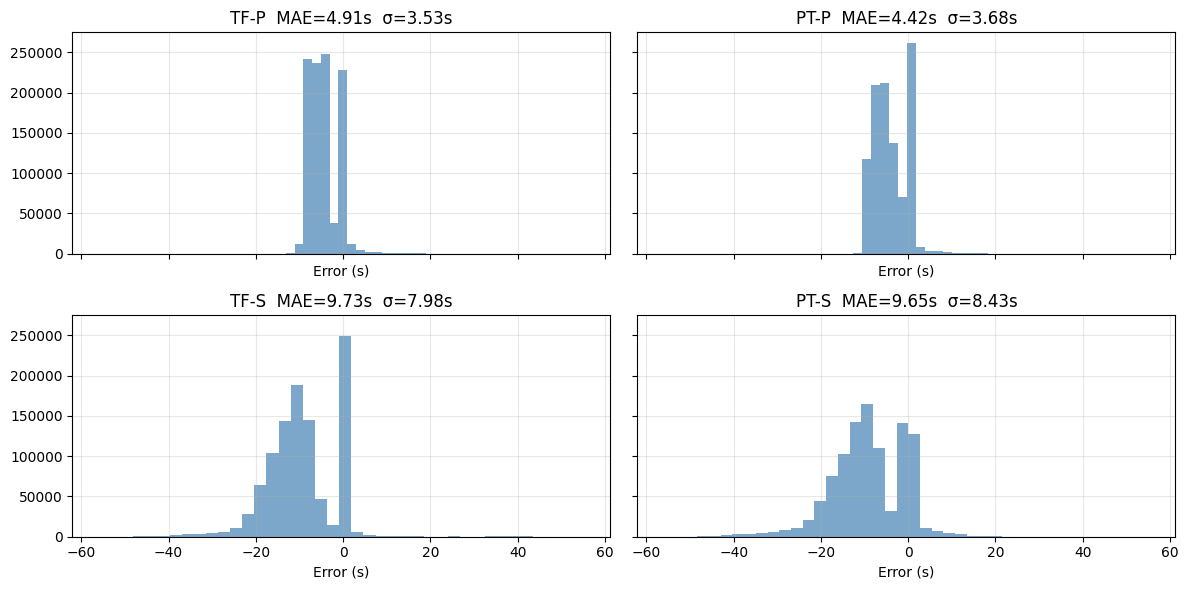

In [23]:
evaluate(s_model="best_refinetuning_modelS_STEAD_TXED_sigma10.pth")